In [1]:
import pandas as pd

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
stk_data=pd.read_csv("Tatacoffee13_21.csv",parse_dates=['Date'],index_col='Date')

In [7]:
stk_data

,Open,High,Low,Close
Date,,,,
2013-01-01,1410.60,1427.90,1408.30,1415.10
2013-01-02,1421.00,1626.60,1416.15,1607.40
2013-01-03,1632.55,1673.90,1613.05,1626.20
2013-01-04,1627.75,1627.75,1574.60,1579.05
2013-01-07,1580.00,1639.50,1565.50,1595.65
...,...,...,...,...
2021-12-22,202.90,207.80,201.35,205.00
2021-12-23,206.00,206.85,202.05,202.95
2021-12-24,203.90,203.90,199.35,201.00


In [9]:
column="Close"

In [11]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (2225, 1)


In [12]:
training_size = round(len(data1 ) * 0.80)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

1780
X_train length: (1780, 1)
X_test length: (445, 1)
y_train length: (1780, 1)
y_test length: (445, 1)


In [43]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from stockFunctions import rmsemape
smoothing_levels=[0.1,0.2,0.3,0.5,0.8]
for i in smoothing_levels:
    model = SimpleExpSmoothing(X_train).fit(smoothing_level=i, optimized=False) 
    y_pred= model.forecast(len(X_test))
    print(f"Alpha:{i}")
    rmsemape(y_test,y_pred)
    print("*****")

  


Alpha:0.1
RMSE-Testset: 0.04756567815233235
maPe-Testset: 198169819638.37106
*****
Alpha:0.2
RMSE-Testset: 0.0505914604351192
maPe-Testset: 157125851048.5571
*****
Alpha:0.3
RMSE-Testset: 0.052061702792087966
maPe-Testset: 137838871001.11716
*****
Alpha:0.5
RMSE-Testset: 0.05341948029285268
maPe-Testset: 120339699253.97025
*****
Alpha:0.8
RMSE-Testset: 0.05412196428121234
maPe-Testset: 111391493150.67743
*****


In [65]:
alpha=0.1
model=SimpleExpSmoothing(X_train).fit(smoothing_level=alpha, optimized=False) 
y_pred= model.forecast(len(X_test))
print(f"Alpha:{alpha}")
rmsemape(y_test,y_pred)

Alpha:0.1
RMSE-Testset: 0.04756567815233235
maPe-Testset: 198169819638.37106


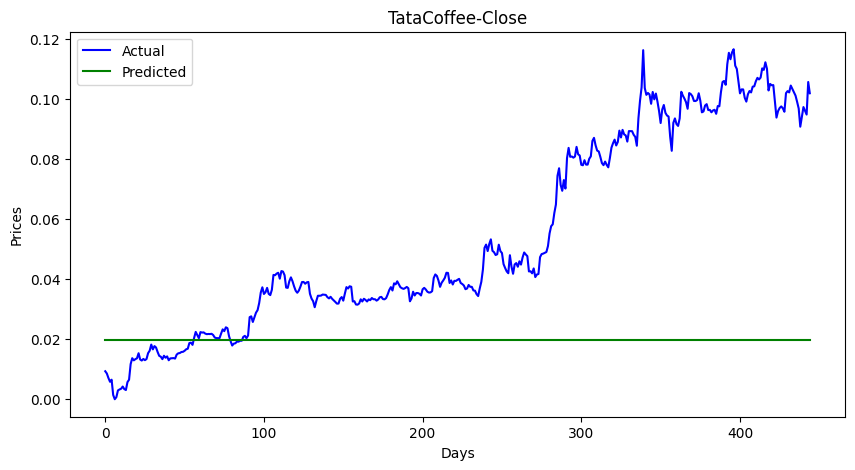

In [67]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","TataCoffee-Close","Days","Prices")

In [69]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,["Close"])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,["Close"])

In [71]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,["Close"])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,["Close"])

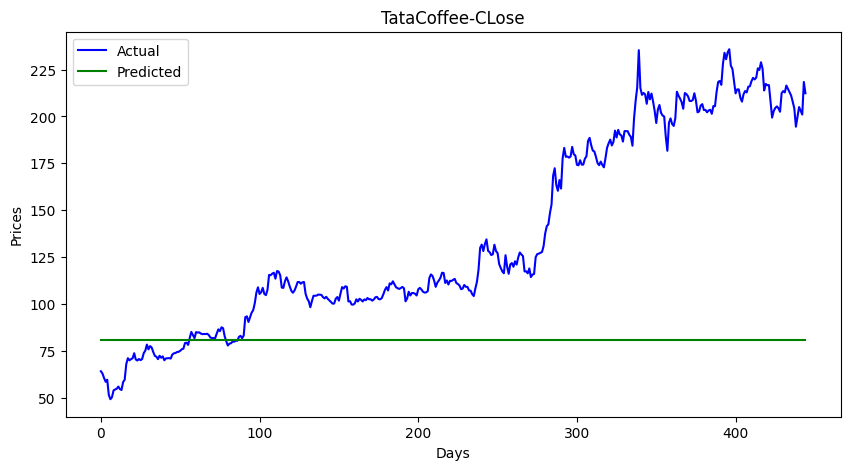

In [73]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-CLose","Days","Prices")

In [75]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 76.04800622994892
maPe-Testset: 0.3594827320372948


In [77]:
forecast=model.forecast(4)

In [79]:
forecast

array([0.01958113, 0.01958113, 0.01958113, 0.01958113])

In [81]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [83]:
forecast_stock_price_test_oriF

,Closefore
0,80.706311
1,80.706311
2,80.706311
3,80.706311
